# Computer Vision Introdcution 

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping


(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_train[0])

(60000, 28, 28)
(60000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 2

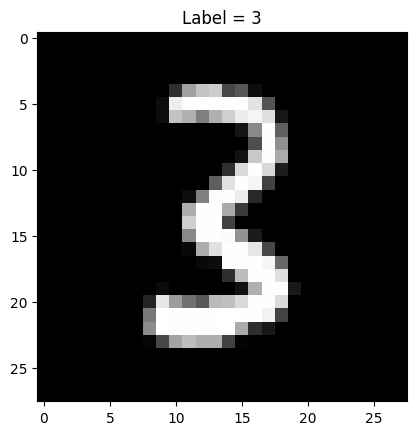

In [7]:
plt.imshow(X_train[50000], cmap='gray')
plt.title(f'Label = {y_train[50000]}')
plt.show()

# Preprocessing

In [7]:
# scaling
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

# Conv layer required channels
X_train_scaled = X_train_scaled.reshape(-1, 28, 28, 1)
X_test_scaled = X_test_scaled.reshape(-1, 28, 28, 1)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# Building CNN

In [19]:
cnn_model = Sequential([
    # 32 filters, each a 3x3 learnable grid — same weighted-sum + activation
    # mechanism as Dense, but SLID across the image rather than applied to
    # the whole input at once. input_shape read dynamically from the data's
    # actual shape (height, width, channels=1 for grayscale)
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                  input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2], X_train_scaled.shape[3])),
    # shrinks each of the 32 feature maps by keeping only the max value in
    # every 2x2 window — reduces size, keeps strongest signals, adds some
    # tolerance to small shifts in where a pattern appears
    layers.MaxPooling2D(pool_size=(2,2)),

    # 64 filters this time — each filter has 32 SEPARATE weight grids inside
    # it (one per incoming feature map from layer 1). Computes 32 partial
    # sums, adds them all into ONE output value per position. Still only
    # 64 total output maps, never 32x64 — the incoming depth gets absorbed
    # inside each filter's own calculation, not multiplied out
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # collapses the final small (height, width, 64) block into one flat
    # list of numbers PER IMAGE — Dense layers have no concept of spatial
    # position, so this is the one moment spatial structure is deliberately
    # thrown away, in exchange for being usable by familiar Dense layers
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),

    # units=10 = one output neuron per digit class (0-9), softmax turns
    # raw scores into probabilities summing to 1 — identical mechanism
    # to the Glass 6-class output layer, just 10 classes instead of 6
    layers.Dense(units=10, activation='softmax')
])

c:\Users\Edward\Desktop\python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile adn train

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # y is plain int labels (0-9), not one-hot
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    X_train_scaled, y_train,
    epochs = 5,
    batch_size = 64,
    validation_data=(X_test_scaled, y_test)
)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9977 - loss: 0.0069 - val_accuracy: 0.9896 - val_loss: 0.0379
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9979 - loss: 0.0059 - val_accuracy: 0.9895 - val_loss: 0.0496
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9910 - val_loss: 0.0375
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9907 - val_loss: 0.0426
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9983 - loss: 0.0048 - val_accuracy: 0.9908 - val_loss: 0.0447


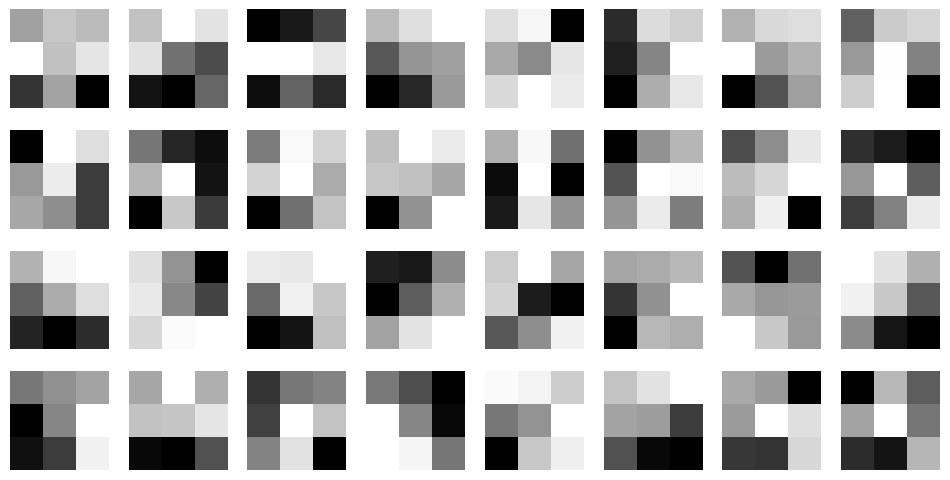

In [18]:
first_conv_layer = cnn_model.layers[0]
filters, biases = first_conv_layer.get_weights()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[:, :, 0, i], cmap='gray')
    ax.axis('off')
plt.show()

# Early Stopping

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

cnn_model_v2 = Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_v2 = cnn_model_v2.fit(
    X_train_scaled, y_train,
    epochs = 15,
    batch_size = 64,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop]
)

print(f"Best val_loss achieved: {min(cnn_history_v2.history['val_loss']):.4f}")
print(f"Corresponding epoch: {cnn_history_v2.history['val_loss'].index(min(cnn_history_v2.history['val_loss'])) + 1}")

# inspect the actual weight values for the first Conv2D layer
first_conv_weights, first_conv_biases = cnn_model_v2.layers[0].get_weights()
print(first_conv_weights.shape)  
print(first_conv_weights[:, :, 0, 0])  # the actual 3x3 numbers for filter #1

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9442 - loss: 0.1831 - val_accuracy: 0.9839 - val_loss: 0.0536
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9834 - loss: 0.0528 - val_accuracy: 0.9844 - val_loss: 0.0454
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9911 - val_loss: 0.0302
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9910 - loss: 0.0279 - val_accuracy: 0.9881 - val_loss: 0.0356
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9926 - loss: 0.0227 - val_accuracy: 0.9904 - val_loss: 0.0289
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9908 - val_loss: 0.0304
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9952 - loss: 0.0144 - val_accuracy: 0.9911 - val_loss: 0.0281
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9962 - loss: 0.0113 - val_accuracy: 0.